<a href="https://colab.research.google.com/github/etoo-blip/Machine-Learning-Homework-2/blob/main/Edwin_Too_Homework_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 2 – Linear Regression with Gradient Descent

**Dataset:** US Housing Dataset

This notebook implements linear regression using gradient descent from scratch.

- 80% training / 20% evaluation split
- Parameters initialized to zero
- Gradient descent implemented manually
- Problem 1: Unscaled input features
- Problem 2: Normalization and standardization
- Problem 3: L2 parameter regularization

In [1]:

# Import libraries and load the housing dataset

from google.colab import files
uploaded = files.upload()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load dataset
housing = pd.read_csv("Housing.csv")

# Display first five rows
housing.head()

Saving Housing.csv to Housing.csv


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:

# Inspect the dataset

print("Dataset shape:", housing.shape)

print(housing.head())

Dataset shape: (545, 13)
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [4]:

# Convert binary categorical variables from yes/no to 1/0

varlist = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

def binary_map(x):
    return x.map({'yes': 1, 'no': 0})

housing[varlist] = housing[varlist].apply(binary_map)

housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [5]:

# Gradient Descent Function
# Used for Problems 1 and 2

def gradient_descent(X_b_train, Y_train, X_b_val, Y_val,
                     learning_rate, n_iterations):

    m = len(X_b_train)

    # Initialize all parameters to zero
    theta = np.zeros((X_b_train.shape[1], 1))

    train_losses = []
    val_losses = []

    for iteration in range(n_iterations):

        # Calculate gradient using the training data
        gradients = (2/m) * X_b_train.T.dot(
            X_b_train.dot(theta) - Y_train
        )

        # Update parameters
        theta = theta - learning_rate * gradients

        # Calculate training MSE
        train_loss = (1/m) * np.sum(
            np.square(X_b_train.dot(theta) - Y_train)
        )

        # Calculate validation MSE
        val_loss = (1/len(X_b_val)) * np.sum(
            np.square(X_b_val.dot(theta) - Y_val)
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return theta, train_losses, val_losses

In [6]:

# Problem 1(a)
# Linear regression using:
# area, bedrooms, bathrooms, stories, parking
# No feature scaling is used in Problem 1

features_1a = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]

X = housing[features_1a].values
Y = housing[['price']].values

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (545, 5)
Y shape: (545, 1)


In [7]:

# Problem 1(a) - 80% training / 20% validation split


X_train, X_val, Y_train, Y_val = train_test_split(
    X,
    Y,
    train_size=0.8,
    test_size=0.2,
    random_state=100
)

# Add a column of ones for the intercept theta_0
X_b_train = np.c_[np.ones((len(X_train), 1)), X_train]
X_b_val = np.c_[np.ones((len(X_val), 1)), X_val]

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_b_train shape:", X_b_train.shape)
print("X_b_val shape:", X_b_val.shape)

X_train shape: (436, 5)
X_val shape: (109, 5)
X_b_train shape: (436, 6)
X_b_val shape: (109, 6)


Learning Rate = 0.01
Final Training Loss: 1.7251766983851592e+129
Final Validation Loss: 1.7634611410713307e+129



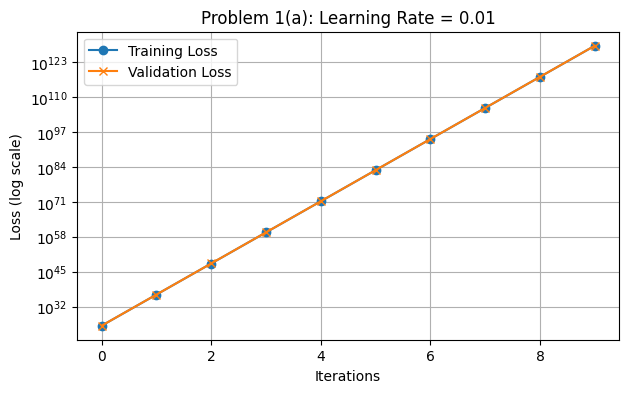

Learning Rate = 0.05
Final Training Loss: 1.6452990431084157e+143
Final Validation Loss: 1.6818108722888456e+143



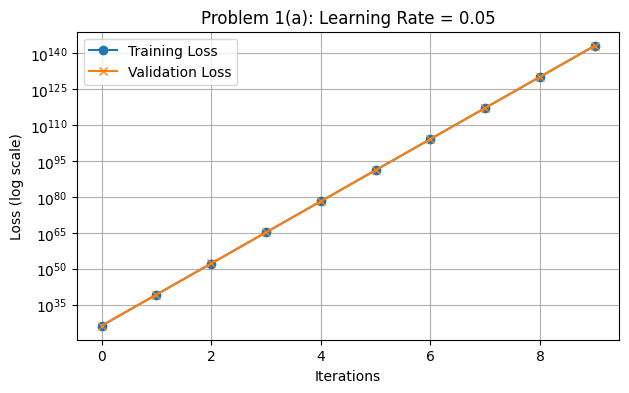

Learning Rate = 0.1
Final Training Loss: 1.7252266383829072e+149
Final Validation Loss: 1.7635121893178652e+149



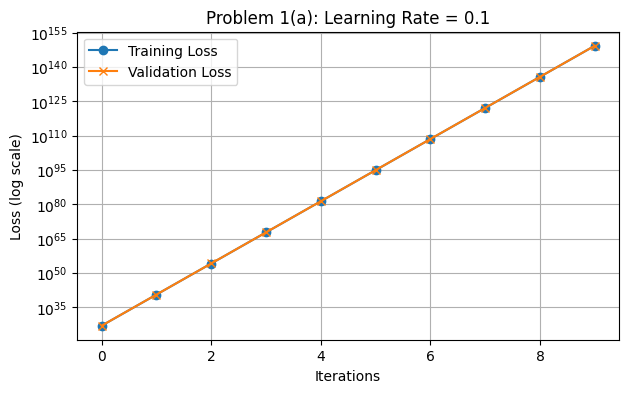

In [8]:

# Problem 1(a) - Required learning-rate trials
# Test learning rates from 0.01 to 0.1 on unscaled data

learning_rates_1a = [0.01, 0.05, 0.1]

for learning_rate in learning_rates_1a:

    theta_temp, train_temp, val_temp = gradient_descent(
        X_b_train,
        Y_train,
        X_b_val,
        Y_val,
        learning_rate=learning_rate,
        n_iterations=10
    )

    print("Learning Rate =", learning_rate)
    print("Final Training Loss:", train_temp[-1])
    print("Final Validation Loss:", val_temp[-1])
    print()

    # Plot training and validation losses
    plt.figure(figsize=(7, 4))
    plt.plot(train_temp, marker='o', label='Training Loss')
    plt.plot(val_temp, marker='x', label='Validation Loss')

    # Log scale makes the rapidly increasing losses easier to see
    plt.yscale('log')

    plt.xlabel('Iterations')
    plt.ylabel('Loss (log scale)')
    plt.title('Problem 1(a): Learning Rate = ' + str(learning_rate))
    plt.legend()
    plt.grid()
    plt.show()

Parameters obtained using learning rate = 1e-9:
[[  7.3604421 ]
 [861.88803695]
 [ 27.67445236]
 [ 16.10440638]
 [ 24.73643588]
 [  5.76207762]]

Final Training Loss: 3380050433661.0703
Final Validation Loss: 3218790338820.6187


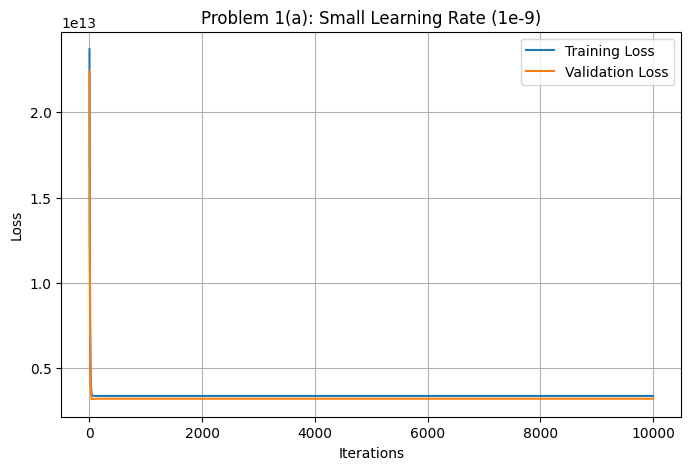

In [9]:

# Problem 1(a) - Additional small learning-rate experiment
#
# The required learning rates diverged because the input
# features are unscaled. A much smaller learning rate is
# tested to demonstrate stable, but slow, convergence.


theta_1a_small, train_1a_small, val_1a_small = gradient_descent(
    X_b_train,
    Y_train,
    X_b_val,
    Y_val,
    learning_rate=1e-9,
    n_iterations=10000
)

print("Parameters obtained using learning rate = 1e-9:")
print(theta_1a_small)

print()
print("Final Training Loss:", train_1a_small[-1])
print("Final Validation Loss:", val_1a_small[-1])

plt.figure(figsize=(8,5))
plt.plot(train_1a_small, label='Training Loss')
plt.plot(val_1a_small, label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Problem 1(a): Small Learning Rate (1e-9)')
plt.legend()
plt.grid()
plt.show()

In [10]:

# Problem 1(b)
# Linear regression using 11 housing features
# No feature scaling is used.

features_1b = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'parking',
    'prefarea'
]

X_1b = housing[features_1b].values
Y_1b = housing[['price']].values

X_train_1b, X_val_1b, Y_train_1b, Y_val_1b = train_test_split(
    X_1b,
    Y_1b,
    train_size=0.8,
    test_size=0.2,
    random_state=100
)

# Add bias column
X_b_train_1b = np.c_[np.ones((len(X_train_1b), 1)), X_train_1b]
X_b_val_1b = np.c_[np.ones((len(X_val_1b), 1)), X_val_1b]

print("X_train shape:", X_train_1b.shape)
print("X_val shape:", X_val_1b.shape)
print("X_b_train shape:", X_b_train_1b.shape)
print("X_b_val shape:", X_b_val_1b.shape)

X_train shape: (436, 11)
X_val shape: (109, 11)
X_b_train shape: (436, 12)
X_b_val shape: (109, 12)


Learning Rate = 0.01
Final Training Loss: 1.7251778324859345e+129
Final Validation Loss: 1.7634622985645042e+129



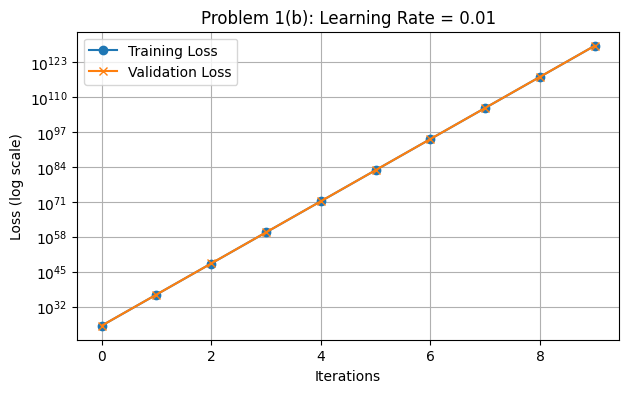

Learning Rate = 0.05
Final Training Loss: 1.6453001246976542e+143
Final Validation Loss: 1.6818119761873574e+143



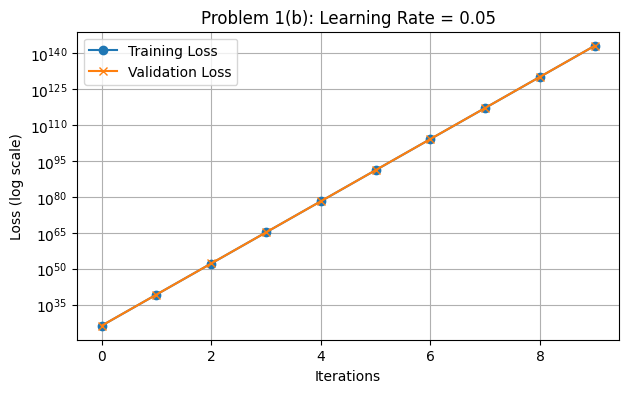

Learning Rate = 0.1
Final Training Loss: 1.7252277725148925e+149
Final Validation Loss: 1.7635133468428895e+149



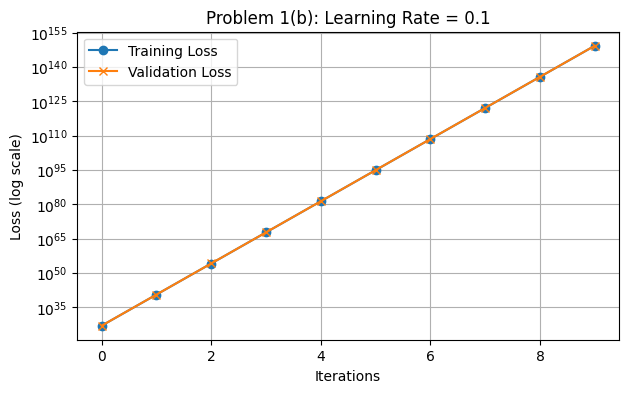

In [11]:

# Problem 1(b) - Required learning-rate trials


learning_rates_1b = [0.01, 0.05, 0.1]

for learning_rate in learning_rates_1b:

    theta_temp, train_temp, val_temp = gradient_descent(
        X_b_train_1b,
        Y_train_1b,
        X_b_val_1b,
        Y_val_1b,
        learning_rate=learning_rate,
        n_iterations=10
    )

    print("Learning Rate =", learning_rate)
    print("Final Training Loss:", train_temp[-1])
    print("Final Validation Loss:", val_temp[-1])
    print()

    plt.figure(figsize=(7,4))
    plt.plot(train_temp, marker='o', label='Training Loss')
    plt.plot(val_temp, marker='x', label='Validation Loss')
    plt.yscale('log')

    plt.xlabel('Iterations')
    plt.ylabel('Loss (log scale)')
    plt.title('Problem 1(b): Learning Rate = ' + str(learning_rate))
    plt.legend()
    plt.grid()
    plt.show()

Parameters obtained using learning rate = 1e-9:
[[  7.36043326]
 [861.8862395 ]
 [ 27.67442454]
 [ 16.10439361]
 [ 24.73641509]
 [  6.31766124]
 [  2.8202137 ]
 [  4.36932649]
 [  1.35758039]
 [  6.19700806]
 [  5.76207341]
 [  2.97557348]]

Final Training Loss: 3380038983389.452
Final Validation Loss: 3218776062741.426


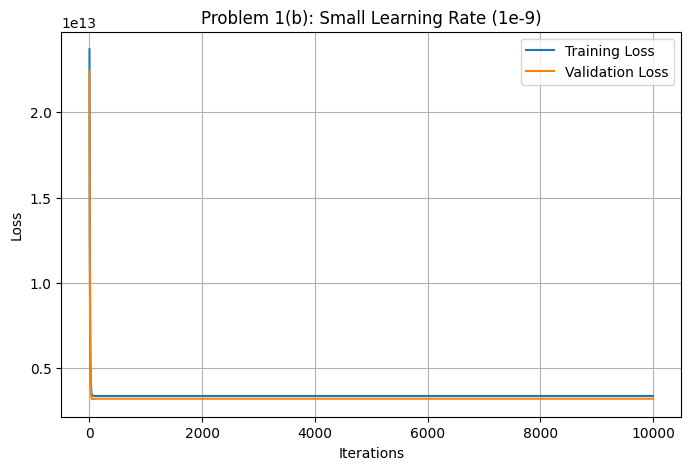

In [12]:
# ============================================================
# Problem 1(b) - Additional small learning-rate experiment
# ============================================================

theta_1b_small, train_1b_small, val_1b_small = gradient_descent(
    X_b_train_1b,
    Y_train_1b,
    X_b_val_1b,
    Y_val_1b,
    learning_rate=1e-9,
    n_iterations=10000
)

print("Parameters obtained using learning rate = 1e-9:")
print(theta_1b_small)

print()
print("Final Training Loss:", train_1b_small[-1])
print("Final Validation Loss:", val_1b_small[-1])

plt.figure(figsize=(8,5))
plt.plot(train_1b_small, label='Training Loss')
plt.plot(val_1b_small, label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Problem 1(b): Small Learning Rate (1e-9)')
plt.legend()
plt.grid()
plt.show()

In [13]:

# Problem 2(a) - Min-Max Normalization
# Same five input features used in Problem 1(a)
# Output price is NOT normalized.

scaler_norm = MinMaxScaler()

# Fit only on training data to avoid data leakage
X_train_norm = scaler_norm.fit_transform(X_train)

# Apply the same transformation to validation data
X_val_norm = scaler_norm.transform(X_val)

# Add bias column
X_b_train_norm = np.c_[
    np.ones((len(X_train_norm), 1)),
    X_train_norm
]

X_b_val_norm = np.c_[
    np.ones((len(X_val_norm), 1)),
    X_val_norm
]

print("Training minimums:", X_train_norm.min(axis=0))
print("Training maximums:", X_train_norm.max(axis=0))

Training minimums: [0. 0. 0. 0. 0.]
Training maximums: [1. 1. 1. 1. 1.]


In [14]:

# Problem 2(a) - Normalization learning-rate trials


learning_rates = [
    0.01, 0.02, 0.03, 0.04, 0.05,
    0.06, 0.07, 0.08, 0.09, 0.10
]

for learning_rate in learning_rates:

    theta_temp, train_temp, val_temp = gradient_descent(
        X_b_train_norm,
        Y_train,
        X_b_val_norm,
        Y_val,
        learning_rate=learning_rate,
        n_iterations=1000
    )

    print(
        "Learning Rate =", learning_rate,
        "| Training Loss =", train_temp[-1],
        "| Validation Loss =", val_temp[-1]
    )

Learning Rate = 0.01 | Training Loss = 1773219221651.638 | Validation Loss = 1574094788821.091
Learning Rate = 0.02 | Training Loss = 1625568922847.3315 | Validation Loss = 1509357158074.0
Learning Rate = 0.03 | Training Loss = 1567659294603.6492 | Validation Loss = 1515355453363.2612
Learning Rate = 0.04 | Training Loss = 1542784692928.6062 | Validation Loss = 1532953887408.94
Learning Rate = 0.05 | Training Loss = 1531737960298.6084 | Validation Loss = 1549540840392.9783
Learning Rate = 0.06 | Training Loss = 1526697015285.6343 | Validation Loss = 1562573696042.0461
Learning Rate = 0.07 | Training Loss = 1524336664730.3274 | Validation Loss = 1572174937078.0044
Learning Rate = 0.08 | Training Loss = 1523204304075.4382 | Validation Loss = 1579064731896.8682
Learning Rate = 0.09 | Training Loss = 1522648702965.2236 | Validation Loss = 1583961416736.2312
Learning Rate = 0.1 | Training Loss = 1522370417889.2415 | Validation Loss = 1587437022659.764


Theta:
[[2518003.64314943]
 [3117577.75372187]
 [1279188.071364  ]
 [2663805.92348784]
 [1708746.60121485]
 [1409548.37910027]]
Final Training Loss: 1625568922847.3315
Final Validation Loss: 1509357158074.0


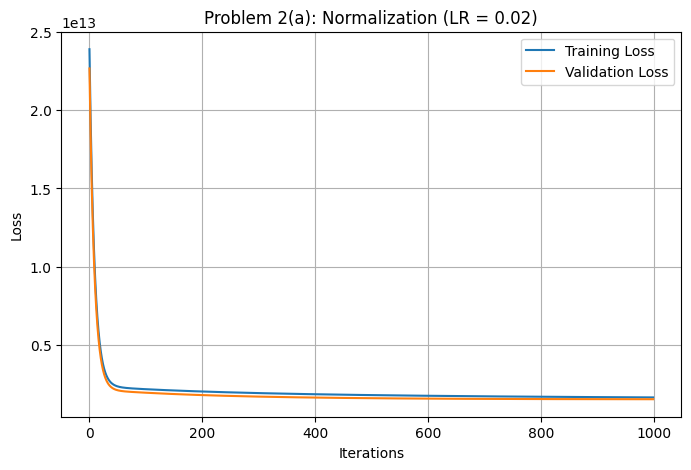

In [15]:

# Problem 2(a) - Selected normalization model
#
# LR = 0.02 produced the lowest validation loss among the
# tested normalization learning rates.

theta_norm_best, train_norm_best, val_norm_best = gradient_descent(
    X_b_train_norm,
    Y_train,
    X_b_val_norm,
    Y_val,
    learning_rate=0.02,
    n_iterations=1000
)

print("Theta:")
print(theta_norm_best)

print("Final Training Loss:", train_norm_best[-1])
print("Final Validation Loss:", val_norm_best[-1])

plt.figure(figsize=(8,5))
plt.plot(train_norm_best, label='Training Loss')
plt.plot(val_norm_best, label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Problem 2(a): Normalization (LR = 0.02)')
plt.legend()
plt.grid()
plt.show()

In [16]:

# Problem 2(a) - Standardization

scaler_std = StandardScaler()

X_train_std = scaler_std.fit_transform(X_train)
X_val_std = scaler_std.transform(X_val)

X_b_train_std = np.c_[
    np.ones((len(X_train_std), 1)),
    X_train_std
]

X_b_val_std = np.c_[
    np.ones((len(X_val_std), 1)),
    X_val_std
]

print("Training means:")
print(X_train_std.mean(axis=0))

print()
print("Training standard deviations:")
print(X_train_std.std(axis=0))

Training means:
[ 6.41688537e-17  2.59731075e-17 -1.19170728e-16  6.84977050e-17
  1.17133622e-17]

Training standard deviations:
[1. 1. 1. 1. 1.]


In [17]:

# Problem 2(a) - Standardization learning-rate trials

for learning_rate in learning_rates:

    theta_temp, train_temp, val_temp = gradient_descent(
        X_b_train_std,
        Y_train,
        X_b_val_std,
        Y_val,
        learning_rate=learning_rate,
        n_iterations=1000
    )

    print(
        "Learning Rate =", learning_rate,
        "| Training Loss =", train_temp[-1],
        "| Validation Loss =", val_temp[-1]
    )

Learning Rate = 0.01 | Training Loss = 1522069682835.0747 | Validation Loss = 1596533657261.4124
Learning Rate = 0.02 | Training Loss = 1522069682826.878 | Validation Loss = 1596534488475.8218
Learning Rate = 0.03 | Training Loss = 1522069682826.878 | Validation Loss = 1596534488482.435
Learning Rate = 0.04 | Training Loss = 1522069682826.878 | Validation Loss = 1596534488482.435
Learning Rate = 0.05 | Training Loss = 1522069682826.878 | Validation Loss = 1596534488482.435
Learning Rate = 0.06 | Training Loss = 1522069682826.878 | Validation Loss = 1596534488482.4353
Learning Rate = 0.07 | Training Loss = 1522069682826.878 | Validation Loss = 1596534488482.4355
Learning Rate = 0.08 | Training Loss = 1522069682826.878 | Validation Loss = 1596534488482.4355
Learning Rate = 0.09 | Training Loss = 1522069682826.878 | Validation Loss = 1596534488482.4355
Learning Rate = 0.1 | Training Loss = 1522069682826.878 | Validation Loss = 1596534488482.4355


Theta:
[[4795729.22018348]
 [ 729932.35589788]
 [  79334.74233422]
 [ 641264.73850838]
 [ 463855.86668605]
 [ 287331.21112435]]
Final Training Loss: 1522069682826.878
Final Validation Loss: 1596534488482.435


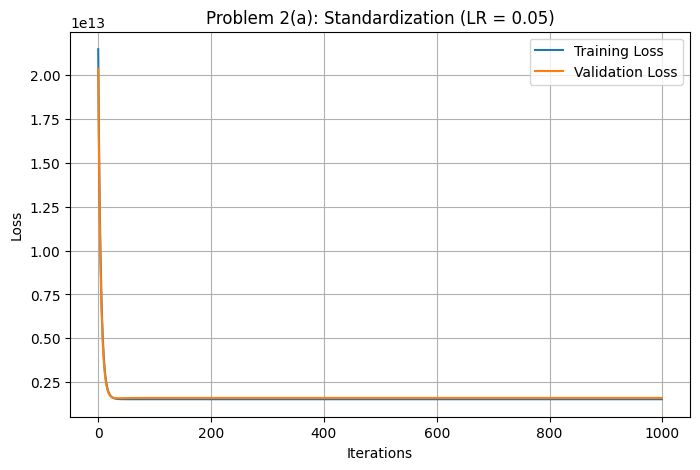

In [18]:

# Problem 2(a) - Selected standardization model
# LR = 0.05 is used as a representative converged run.

theta_std_best, train_std_best, val_std_best = gradient_descent(
    X_b_train_std,
    Y_train,
    X_b_val_std,
    Y_val,
    learning_rate=0.05,
    n_iterations=1000
)

print("Theta:")
print(theta_std_best)

print("Final Training Loss:", train_std_best[-1])
print("Final Validation Loss:", val_std_best[-1])

plt.figure(figsize=(8,5))
plt.plot(train_std_best, label='Training Loss')
plt.plot(val_std_best, label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Problem 2(a): Standardization (LR = 0.05)')
plt.legend()
plt.grid()
plt.show()

In [19]:

# Problem 2(b) - Min-Max Normalization


scaler_norm_2b = MinMaxScaler()

X_train_norm_2b = scaler_norm_2b.fit_transform(X_train_1b)
X_val_norm_2b = scaler_norm_2b.transform(X_val_1b)

X_b_train_norm_2b = np.c_[
    np.ones((len(X_train_norm_2b), 1)),
    X_train_norm_2b
]

X_b_val_norm_2b = np.c_[
    np.ones((len(X_val_norm_2b), 1)),
    X_val_norm_2b
]

print("Training minimums:")
print(X_train_norm_2b.min(axis=0))

print()
print("Training maximums:")
print(X_train_norm_2b.max(axis=0))

Training minimums:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Training maximums:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [20]:

# Problem 2(b) - Normalization learning-rate trials


for learning_rate in learning_rates:

    theta_temp, train_temp, val_temp = gradient_descent(
        X_b_train_norm_2b,
        Y_train_1b,
        X_b_val_norm_2b,
        Y_val_1b,
        learning_rate=learning_rate,
        n_iterations=1000
    )

    print(
        "Learning Rate =", learning_rate,
        "| Training Loss =", train_temp[-1],
        "| Validation Loss =", val_temp[-1]
    )

Learning Rate = 0.01 | Training Loss = 1318330373785.5483 | Validation Loss = 1175731712742.9927
Learning Rate = 0.02 | Training Loss = 1218349612798.4175 | Validation Loss = 1113773392239.4736
Learning Rate = 0.03 | Training Loss = 1180579588758.717 | Validation Loss = 1112678216582.5342
Learning Rate = 0.04 | Training Loss = 1163871443503.1997 | Validation Loss = 1122115095943.0552
Learning Rate = 0.05 | Training Loss = 1156113771222.7014 | Validation Loss = 1131524382068.9607
Learning Rate = 0.06 | Training Loss = 1152382584934.6704 | Validation Loss = 1138824002601.9475
Learning Rate = 0.07 | Training Loss = 1150528019571.2825 | Validation Loss = 1144045023064.56
Learning Rate = 0.08 | Training Loss = 1149577767621.1536 | Validation Loss = 1147659136063.3596
Learning Rate = 0.09 | Training Loss = 1149077584430.2417 | Validation Loss = 1150130473661.2207
Learning Rate = 0.1 | Training Loss = 1148808200923.1416 | Validation Loss = 1151817907446.9575


Theta:
[[1695033.53776959]
 [2548155.84076314]
 [1004008.01528485]
 [2765003.29412527]
 [1280731.69012335]
 [ 696688.65757393]
 [ 468034.72970611]
 [ 294256.50520777]
 [ 913038.2249473 ]
 [ 933573.58292033]
 [ 978452.15759236]
 [ 653280.78843123]]
Final Training Loss: 1180579588758.717
Final Validation Loss: 1112678216582.5342


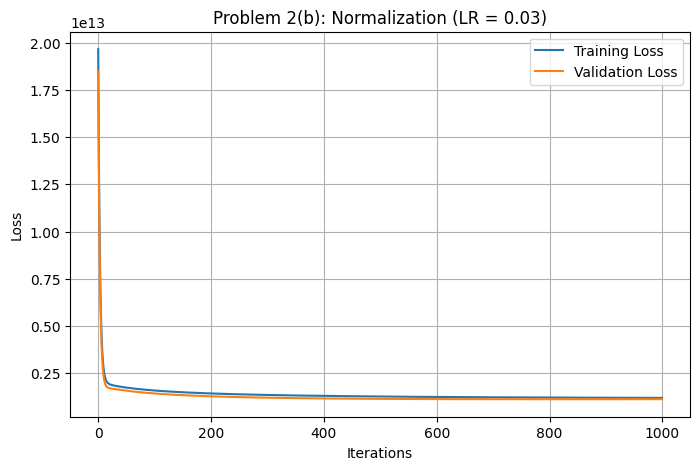

In [21]:

# Problem 2(b) - Selected normalization model
# LR = 0.03 gave the lowest validation loss among tested rates.


theta_norm_2b_best, train_norm_2b_best, val_norm_2b_best = gradient_descent(
    X_b_train_norm_2b,
    Y_train_1b,
    X_b_val_norm_2b,
    Y_val_1b,
    learning_rate=0.03,
    n_iterations=1000
)

print("Theta:")
print(theta_norm_2b_best)

print("Final Training Loss:", train_norm_2b_best[-1])
print("Final Validation Loss:", val_norm_2b_best[-1])

plt.figure(figsize=(8,5))
plt.plot(train_norm_2b_best, label='Training Loss')
plt.plot(val_norm_2b_best, label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Problem 2(b): Normalization (LR = 0.03)')
plt.legend()
plt.grid()
plt.show()

In [22]:

# Problem 2(b) - Standardization


scaler_std_2b = StandardScaler()

X_train_std_2b = scaler_std_2b.fit_transform(X_train_1b)
X_val_std_2b = scaler_std_2b.transform(X_val_1b)

X_b_train_std_2b = np.c_[
    np.ones((len(X_train_std_2b), 1)),
    X_train_std_2b
]

X_b_val_std_2b = np.c_[
    np.ones((len(X_val_std_2b), 1)),
    X_val_std_2b
]

print("Training means:")
print(X_train_std_2b.mean(axis=0))

print()
print("Training standard deviations:")
print(X_train_std_2b.std(axis=0))

Training means:
[ 6.41688537e-17  2.59731075e-17 -1.19170728e-16  6.84977050e-17
 -2.76791841e-16 -3.42488525e-17  3.00473204e-17  1.25409367e-16
  4.48163423e-17  1.17133622e-17  2.39360010e-17]

Training standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [23]:

# Problem 2(b) - Standardization learning-rate trials


for learning_rate in learning_rates:

    theta_temp, train_temp, val_temp = gradient_descent(
        X_b_train_std_2b,
        Y_train_1b,
        X_b_val_std_2b,
        Y_val_1b,
        learning_rate=learning_rate,
        n_iterations=1000
    )

    print(
        "Learning Rate =", learning_rate,
        "| Training Loss =", train_temp[-1],
        "| Validation Loss =", val_temp[-1]
    )

Learning Rate = 0.01 | Training Loss = 1148468649614.029 | Validation Loss = 1155918475298.8218
Learning Rate = 0.02 | Training Loss = 1148468648799.6167 | Validation Loss = 1155909649192.209
Learning Rate = 0.03 | Training Loss = 1148468648799.6165 | Validation Loss = 1155909646500.486
Learning Rate = 0.04 | Training Loss = 1148468648799.6167 | Validation Loss = 1155909646499.7634
Learning Rate = 0.05 | Training Loss = 1148468648799.6167 | Validation Loss = 1155909646499.7634
Learning Rate = 0.06 | Training Loss = 1148468648799.6167 | Validation Loss = 1155909646499.7637
Learning Rate = 0.07 | Training Loss = 1148468648799.6167 | Validation Loss = 1155909646499.7634
Learning Rate = 0.08 | Training Loss = 1148468648799.6165 | Validation Loss = 1155909646499.7634
Learning Rate = 0.09 | Training Loss = 1148468648799.6165 | Validation Loss = 1155909646499.7634
Learning Rate = 0.1 | Training Loss = 1148468648799.6165 | Validation Loss = 1155909646499.7632


Theta:
[[4795729.22018348]
 [ 532835.69216043]
 [  72722.23626589]
 [ 578491.7697621 ]
 [ 367612.68146468]
 [ 210296.49665032]
 [ 146049.33372718]
 [ 145415.81424273]
 [ 204958.54051814]
 [ 399907.03100229]
 [ 222497.59400621]
 [ 255724.44683731]]
Final Training Loss: 1148468648799.6167
Final Validation Loss: 1155909646499.7634


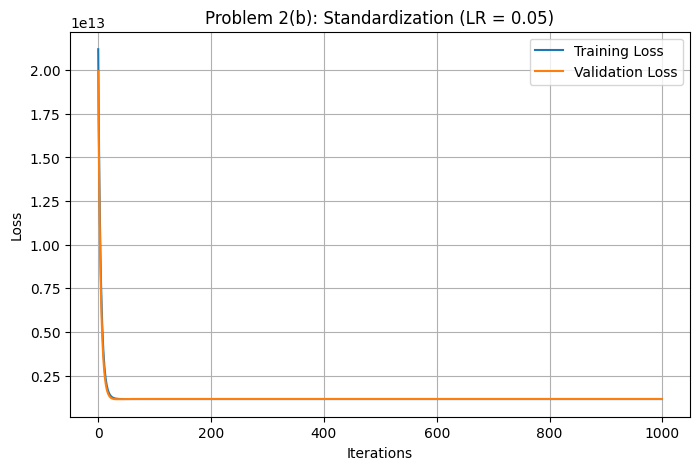

In [24]:

# Problem 2(b) - Selected standardization model


theta_std_2b_best, train_std_2b_best, val_std_2b_best = gradient_descent(
    X_b_train_std_2b,
    Y_train_1b,
    X_b_val_std_2b,
    Y_val_1b,
    learning_rate=0.05,
    n_iterations=1000
)

print("Theta:")
print(theta_std_2b_best)

print("Final Training Loss:", train_std_2b_best[-1])
print("Final Validation Loss:", val_std_2b_best[-1])

plt.figure(figsize=(8,5))
plt.plot(train_std_2b_best, label='Training Loss')
plt.plot(val_std_2b_best, label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Problem 2(b): Standardization (LR = 0.05)')
plt.legend()
plt.grid()
plt.show()

In [26]:
# Problem 3 - Gradient Descent with L2 Parameter Penalty
# The intercept theta_0 is not regularized.
# Validation loss remains ordinary MSE.

def gradient_descent_regularized(
    X_b_train, Y_train, X_b_val, Y_val,
    learning_rate, n_iterations, lambda_value
):

    m = len(X_b_train)

    # Initialize theta to zero
    theta = np.zeros((X_b_train.shape[1], 1))

    train_losses = []
    val_losses = []

    for iteration in range(n_iterations):

        # Gradient of ordinary MSE
        gradients = (2/m) * X_b_train.T.dot(
            X_b_train.dot(theta) - Y_train
        )

        # L2 regularization gradient
        regularization = (2 * lambda_value / m) * theta

        # Do not regularize intercept theta_0
        regularization[0] = 0

        # Add penalty gradient
        gradients = gradients + regularization

        # Update parameters
        theta = theta - learning_rate * gradients

        # Ordinary training MSE
        train_loss = (1/m) * np.sum(
            np.square(X_b_train.dot(theta) - Y_train)
        )

        # L2 parameter penalty
        penalty = (lambda_value / m) * np.sum(
            np.square(theta[1:])
        )

        # Regularized training objective
        train_loss = train_loss + penalty

        # Validation loss remains ordinary MSE
        val_loss = (1/len(X_b_val)) * np.sum(
            np.square(X_b_val.dot(theta) - Y_val)
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return theta, train_losses, val_losses

In [27]:

# Problem 3(a) - Broad search for regularization strength
# Best scaling from Problem 2(a)

lambda_values_3a = [
    0, 0.01, 0.1, 1, 10, 100,
    200, 500, 1000, 2000, 5000
]

for lambda_value in lambda_values_3a:

    theta_temp, train_temp, val_temp = gradient_descent_regularized(
        X_b_train_std,
        Y_train,
        X_b_val_std,
        Y_val,
        learning_rate=0.05,
        n_iterations=1000,
        lambda_value=lambda_value
    )

    print(
        "Lambda =", lambda_value,
        "| Training Loss =", train_temp[-1],
        "| Validation Loss =", val_temp[-1]
    )

Lambda = 0 | Training Loss = 1522069682826.878 | Validation Loss = 1596534488482.435
Lambda = 0.01 | Training Loss = 1522098307020.9983 | Validation Loss = 1596526372074.777
Lambda = 0.1 | Training Loss = 1522355878671.0884 | Validation Loss = 1596453399506.5327
Lambda = 1 | Training Loss = 1524927042254.4695 | Validation Loss = 1595731077656.9387
Lambda = 10 | Training Loss = 1550193754336.0688 | Validation Loss = 1589218373600.091
Lambda = 100 | Training Loss = 1766439279013.3535 | Validation Loss = 1573928928126.7524
Lambda = 200 | Training Loss = 1951434529230.447 | Validation Loss = 1613089627542.4497
Lambda = 500 | Training Loss = 2318541469817.8926 | Validation Loss = 1820168647327.393
Lambda = 1000 | Training Loss = 2646680081933.5234 | Validation Loss = 2144692898044.3184
Lambda = 2000 | Training Loss = 2945965721287.5337 | Validation Loss = 2553963617187.011
Lambda = 5000 | Training Loss = 3222043912028.9497 | Validation Loss = 3027491971163.0947


In [28]:

# Problem 3(a) - Refined lambda search
# The broad search showed that the best region was near 100.


lambda_values_3a_refined = [50, 75, 100, 125, 150]

for lambda_value in lambda_values_3a_refined:

    theta_temp, train_temp, val_temp = gradient_descent_regularized(
        X_b_train_std,
        Y_train,
        X_b_val_std,
        Y_val,
        learning_rate=0.05,
        n_iterations=1000,
        lambda_value=lambda_value
    )

    print(
        "Lambda =", lambda_value,
        "| Training Loss =", train_temp[-1],
        "| Validation Loss =", val_temp[-1]
    )

Lambda = 50 | Training Loss = 1653698140417.469 | Validation Loss = 1573179383374.9895
Lambda = 75 | Training Loss = 1712109986964.7737 | Validation Loss = 1571287565677.1365
Lambda = 100 | Training Loss = 1766439279013.3535 | Validation Loss = 1573928928126.7524
Lambda = 125 | Training Loss = 1817169677380.7869 | Validation Loss = 1580103239794.749
Lambda = 150 | Training Loss = 1864699102142.5105 | Validation Loss = 1589055121515.085


Final Parameters:
[[4795729.22018348]
 [ 636030.24007795]
 [ 124392.12797733]
 [ 564722.11475207]
 [ 406823.29643816]
 [ 277715.0920073 ]]

Final Regularized Training Loss: 1712109986964.7737
Final Validation Loss: 1571287565677.1365


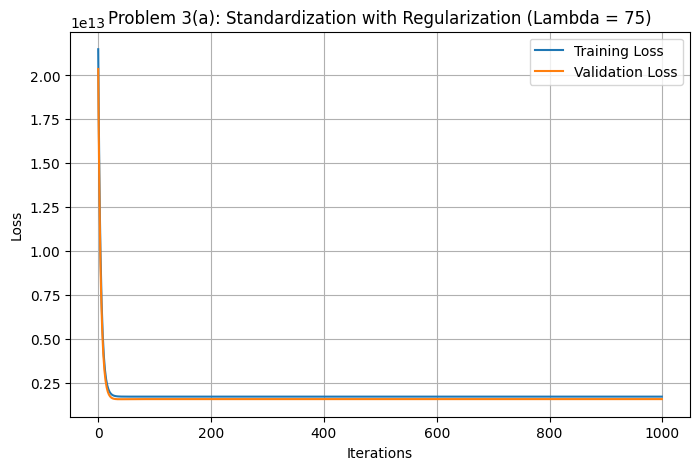

In [29]:

# Problem 3(a) - Final selected model
# Standardization
# Learning rate = 0.05
# Iterations = 1000
# Lambda = 75


theta_3a, train_3a, val_3a = gradient_descent_regularized(
    X_b_train_std,
    Y_train,
    X_b_val_std,
    Y_val,
    learning_rate=0.05,
    n_iterations=1000,
    lambda_value=75
)

print("Final Parameters:")
print(theta_3a)

print()
print("Final Regularized Training Loss:", train_3a[-1])
print("Final Validation Loss:", val_3a[-1])

plt.figure(figsize=(8,5))
plt.plot(train_3a, label='Training Loss')
plt.plot(val_3a, label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Problem 3(a): Standardization with Regularization (Lambda = 75)')
plt.legend()
plt.grid()
plt.show()

In [30]:

# Problem 3(b) - Broad lambda search
# Best scaling from Problem 2(b)


lambda_values_3b = [
    0, 0.01, 0.1, 1, 10,
    50, 75, 100, 200, 500
]

for lambda_value in lambda_values_3b:

    theta_temp, train_temp, val_temp = gradient_descent_regularized(
        X_b_train_std_2b,
        Y_train_1b,
        X_b_val_std_2b,
        Y_val_1b,
        learning_rate=0.05,
        n_iterations=1000,
        lambda_value=lambda_value
    )

    print(
        "Lambda =", lambda_value,
        "| Training Loss =", train_temp[-1],
        "| Validation Loss =", val_temp[-1]
    )

Lambda = 0 | Training Loss = 1148468648799.6167 | Validation Loss = 1155909646499.7634
Lambda = 0.01 | Training Loss = 1148495311919.1987 | Validation Loss = 1155904761737.7598
Lambda = 0.1 | Training Loss = 1148735245348.4082 | Validation Loss = 1155860842820.5684
Lambda = 1 | Training Loss = 1151131157006.3193 | Validation Loss = 1155425988767.346
Lambda = 10 | Training Loss = 1174755196474.6428 | Validation Loss = 1151496526276.96
Lambda = 50 | Training Loss = 1273064776624.4912 | Validation Loss = 1141921453404.5635
Lambda = 75 | Training Loss = 1329656361100.4453 | Validation Loss = 1141196008166.3967
Lambda = 100 | Training Loss = 1383025927734.2495 | Validation Loss = 1143621836976.7727
Lambda = 200 | Training Loss = 1570161828808.5098 | Validation Loss = 1175398949388.609
Lambda = 500 | Training Loss = 1967226635164.3533 | Validation Loss = 1360530008101.4233


In [31]:

# Problem 3(b) - Refined lambda search

lambda_values_3b_refined = [
    55, 60, 65, 70, 75, 80, 85, 90
]

for lambda_value in lambda_values_3b_refined:

    theta_temp, train_temp, val_temp = gradient_descent_regularized(
        X_b_train_std_2b,
        Y_train_1b,
        X_b_val_std_2b,
        Y_val_1b,
        learning_rate=0.05,
        n_iterations=1000,
        lambda_value=lambda_value
    )

    print(
        "Lambda =", lambda_value,
        "| Training Loss =", train_temp[-1],
        "| Validation Loss =", val_temp[-1]
    )

Lambda = 55 | Training Loss = 1284659174238.5837 | Validation Loss = 1141493029102.1282
Lambda = 60 | Training Loss = 1296112212599.4639 | Validation Loss = 1141212040153.383
Lambda = 65 | Training Loss = 1307427283363.42 | Validation Loss = 1141072562963.7437
Lambda = 70 | Training Loss = 1318607630683.2915 | Validation Loss = 1141068990506.8257
Lambda = 75 | Training Loss = 1329656361100.4453 | Validation Loss = 1141196008166.3967
Lambda = 80 | Training Loss = 1340576452553.3943 | Validation Loss = 1141448572003.8096
Lambda = 85 | Training Loss = 1351370762599.7366 | Validation Loss = 1141821889153.7231
Lambda = 90 | Training Loss = 1362042035935.6658 | Validation Loss = 1142311400093.526


Final Parameters:
[[4795729.22018348]
 [ 478781.29142019]
 [ 110032.48045916]
 [ 514154.45404498]
 [ 331379.38099756]
 [ 205423.77999474]
 [ 150984.48588337]
 [ 128937.67687154]
 [ 175921.27128262]
 [ 368760.47178128]
 [ 220369.91687075]
 [ 237743.94527892]]

Final Regularized Training Loss: 1318607630683.2915
Final Validation Loss: 1141068990506.8257


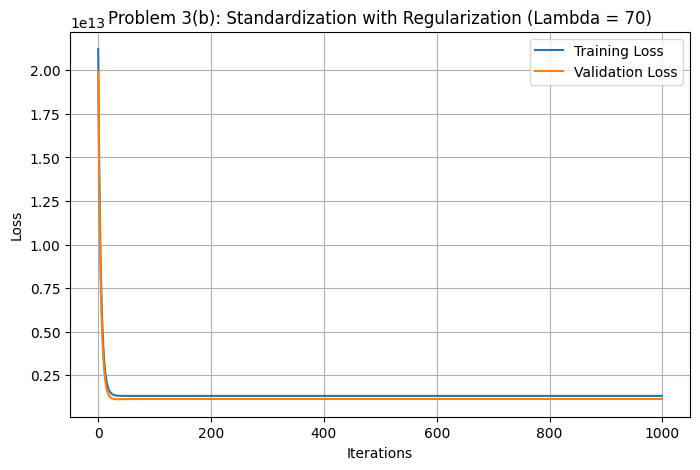

In [33]:

# Problem 3(b) - Final selected model
# Standardization
# Learning rate = 0.05
# Iterations = 1000
# Lambda = 70
#
theta_3b, train_3b, val_3b = gradient_descent_regularized(
    X_b_train_std_2b,
    Y_train_1b,
    X_b_val_std_2b,
    Y_val_1b,
    learning_rate=0.05,
    n_iterations=1000,
    lambda_value=70
)

print("Final Parameters:")
print(theta_3b)

print()
print("Final Regularized Training Loss:", train_3b[-1])
print("Final Validation Loss:", val_3b[-1])

plt.figure(figsize=(8,5))
plt.plot(train_3b, label='Training Loss')
plt.plot(val_3b, label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Problem 3(b): Standardization with Regularization (Lambda = 70)')
plt.legend()
plt.grid()
plt.show()